# Latent SOPE: Off-Policy Evaluation via Latent Trajectory Diffusion

## The Big Idea

We want to answer the question: **"How good is a target policy, without running it?"**

Standard OPE methods struggle in high-dimensional robotic control because they operate
directly on raw observations. Our approach:

1. Use a **robomimic-trained policy** to extract compact latent representations of states
2. Train a **trajectory chunk diffusion model** (à la Stitch-OPE) in that latent space
3. Use **policy-guided sampling** to generate synthetic rollouts that the target policy *would* produce
4. **Score** those synthetic rollouts to estimate the target policy's expected return

Working in latent space gives us lower dimensionality, smoother structure, and
representations that are already tuned to the task — all of which should make diffusion
modeling and OPE more tractable.

## Step-by-Step Pipeline

---

### Step 0: Ground Truth (Oracle Baseline)

**Goal:** Establish the true value of the target policy so we have something to evaluate against.

- Roll out the **target policy** in the environment for many episodes.
- Compute the mean discounted return: $V^\pi = \mathbb{E}[\sum_t \gamma^t r_t]$.
- This is the number our OPE method is trying to estimate *without* running the target policy.

> **What we need:** A trained robomimic policy, a robomimic environment, rollout infrastructure.
> Already have: `rollout()`, `build_rollout_policy_from_checkpoint()`, `build_env_from_checkpoint()`.

---

### Step 1: Collect Offline Data (Behavior Policy Rollouts)

**Goal:** Generate the offline dataset that the diffusion model will learn from.

- Roll out a **behavior policy** (could be the same policy, a different checkpoint, a random
  policy, or a mixture) in the environment.
- At each timestep, record:
  - **Latent state** $z_t$: extracted from the behavior policy's encoder via `PolicyFeatureHook`,
    or by concatenating low-dim obs via `LowDimConcatEncoder`
  - **Action** $a_t$: the action the behavior policy actually took
  - **Reward** $r_t$, **done** flag
- Save as `RolloutLatentTrajectory` (`.h5` / `.npz`).
- Repeat for many episodes to build a large offline dataset.

> **What we need:** Behavior policy checkpoint(s), encoder choice, `RolloutLatentRecorder`.
> Already have: full recording pipeline in `rollout.py`.
>
> **Sub-questions to resolve:**
> - Which encoder? `LowDimConcatEncoder` (interpretable, reversible) vs `HighDimObsEncoder`
>   (richer but opaque). Low-dim concat is the safe starting point.
> - How many rollouts? Enough to cover the state-action space — probably hundreds to low thousands.
> - Should the behavior policy match the target policy? Not necessarily — diversity helps the
>   diffusion model, but too much distribution shift hurts guidance.

---

### Step 2: Chunk the Offline Data

**Goal:** Turn long trajectories into short overlapping chunks for diffusion training.

- Load saved `RolloutLatentTrajectory` files.
- Slice each trajectory into chunks using `RolloutChunkDataset`:
  - **Conditioning context** (frame_stack): the last few $(z, a)$ pairs *before* the chunk
  - **Target chunk** (chunk_size): the next $W$ steps of $(z, a)$ pairs to predict
- Compute **normalization statistics** (mean/std) across the full dataset.
- Build a PyTorch `DataLoader`.

> **What we need:** Choice of `chunk_size`, `stride`, `frame_stack`.
> Already have: `make_rollout_chunk_dataloader()`, `RolloutChunkDatasetConfig`.
>
> **Sub-questions to resolve:**
> - `chunk_size`: Stitch-OPE uses 8 on D4RL. Robomimic horizons are shorter (~60–400 steps),
>   so 8 is a reasonable starting point. Needs tuning.
> - `frame_stack`: 2 is the default. Matches robomimic's typical frame stacking.
> - `stride`: Controls overlap / dataset size tradeoff. Stride 1 = max data, stride = chunk_size = no overlap.

---

### Step 3: Train the Chunk Diffusion Model

**Goal:** Learn the joint distribution $p(z_{t:t+W}, a_{t:t+W})$ of latent trajectory chunks.

- Instantiate `SopeDiffuser` (wraps `TemporalUnet` + `GaussianDiffusion`).
- Each training step:
  1. Sample a batch of chunks from the DataLoader
  2. Concatenate states and actions into a single sequence: shape $(B, W, D_z + D_a)$
  3. Condition on the frame-stack states (pin the first few timesteps)
  4. Run DDPM forward process: add noise at a random diffusion timestep $t$
  5. Predict the noise (or the clean sample) with the TemporalUnet
  6. Compute L2 loss (with `action_weight` upweighting actions)
  7. Backprop + gradient clip + optimizer step
- Save checkpoints periodically.

> **What we need:** Diffusion hyperparameters, sufficient training compute.
> Already have: `train()` in `diffusion/train.py`, `SopeDiffusionConfig`, `TrainingConfig`.
>
> **Sub-questions to resolve:**
> - `diffusion_steps`: 256 is the SOPE default. More = better quality but slower sampling.
> - `dim_mults`: Controls UNet capacity. `(1, 2)` for small latent dims, `(1, 2, 4)` for larger.
> - `action_weight`: 5.0 is the SOPE default. Ensures actions are well-modeled since they're
>   critical for policy evaluation.
> - How long to train? Monitor loss convergence. D4RL SOPE uses ~100k steps.

---

### Step 4: Policy Guidance Setup

**Goal:** Prepare the target and behavior policies so the diffusion model can steer samples
toward the target policy's distribution.

- The target policy needs to provide $\nabla_a \log \pi_{\text{target}}(a \mid z)$ — the
  score function w.r.t. actions given a latent state.
- The behavior policy (optionally) provides $\nabla_a \log \pi_{\text{behavior}}(a \mid z)$
  for negative guidance (contrastive de-biasing).
- These gradients are computed via `torch.autograd` during the diffusion sampling loop.

> **What we need:** Policy wrappers that expose `grad_log_prob(state, action)`.
> Already have (partially): SOPE's `GaussianDiffusion` has the guidance mechanism built in,
> but the policy interface (`gradlog_diffusion`) expects D4RL-style policies.
>
> **Sub-questions to resolve (this is the hardest step):**
> - Robomimic policies don't natively expose log-probabilities. We need a wrapper.
>   - For Gaussian policies (BC_Gaussian): can extract mean/std and compute log-prob analytically.
>   - For GMM policies (BC_GMM): log-sum-exp over mixture components.
>   - For deterministic policies (BC): need to add noise or use a surrogate.
>   - For diffusion policies (DiffusionPolicyUNet): can use the diffusion score directly.
> - The policies operate on *observations*, but our diffusion model operates on *latents*.
>   If using `LowDimConcatEncoder`, latents = concatenated obs, so policies work directly.
>   If using `HighDimObsEncoder`, we'd need to map latents back to obs (hard/lossy).
> - Guidance hyperparameters (`action_scale`, `use_neg_grad`, `normalize_grad`, etc.) need tuning.

---

### Step 5: Generate Synthetic Trajectories via Stitching

**Goal:** Sample full-length trajectories from the guided diffusion model.

- Pick initial states from the offline dataset (or a starting state distribution).
- **Stitching loop:**
  1. Condition on the current state (normalized)
  2. Sample a chunk of length $W$ from the diffusion model, with policy guidance
  3. Extract the generated $(z, a)$ pairs from the chunk
  4. Check for termination (if we have a termination predictor)
  5. Set the last state of this chunk as the starting state for the next chunk
  6. Repeat until max trajectory length or termination
- Collect $N$ synthetic trajectories (e.g., $N = 50$–$1000$).

> **What we need:** Stitching loop, termination predictor, initial state distribution.
> Already have (partially): SOPE's `Diffuser.generate_full_trajectory()` does this for D4RL.
> `SopeDiffuser` has `sample()` but the stitching loop is marked as a TODO.
>
> **Sub-questions to resolve:**
> - Termination: D4RL envs have simple termination conditions (e.g., Hopper falls over).
>   Robomimic tasks may not have natural termination — just a fixed horizon. Do we even need
>   a termination predictor, or just run for the full horizon?
> - How many trajectories? More = lower variance OPE estimate, but more compute.
> - Quality checks: are the stitched trajectories physically plausible? Do states stay in-distribution?

---

### Step 6: Score Trajectories (Reward Estimation)

**Goal:** Assign a return to each synthetic trajectory.

- **Option A: Use ground-truth reward function** — If the reward function $R(s, a)$ is known
  (as it often is in simulation), directly compute rewards for each $(z_t, a_t)$ pair.
  But: the reward function takes *observations*, not latents. With `LowDimConcatEncoder`,
  we can decode latents back to obs. With learned encoders, this is harder.

- **Option B: Train a reward estimator** — Learn $\hat{R}(z, a)$ from the offline data,
  mapping latent states and actions to scalar rewards. This is a supervised regression
  problem on the offline dataset's $(z_t, a_t, r_t)$ tuples.

- Compute the discounted return for each trajectory:
  $\hat{V} = \sum_{t=0}^{T} \gamma^t \hat{R}(z_t, a_t)$

- The **OPE estimate** is the mean return across all synthetic trajectories.

> **What we need:** Reward function access or a learned reward model.
>
> **Sub-questions to resolve:**
> - If using `LowDimConcatEncoder` and the env's reward is a known function of obs + action,
>   we can decode and use the true reward. This is the cleanest path.
> - If reward depends on quantities not in the latent (e.g., contact forces), we need a learned
>   estimator. How accurate does it need to be? Reward estimation error compounds over the horizon.
> - Discount factor $\gamma$: typically 0.99 for D4RL. Robomimic tasks may use $\gamma = 1.0$
>   (finite horizon, no discounting) or task-specific values.

---

### Step 7: Evaluate the OPE Estimate

**Goal:** Compare our estimate to the ground truth from Step 0.

- **Metrics:**
  - **MSE**: $(\hat{V} - V^{\pi})^2$ — how close is the estimate?
  - **Rank correlation**: Given multiple target policies, does our method rank them correctly?
    (Spearman correlation between estimated and true values.)
  - **Regret@k**: If we pick the top-$k$ policies by our estimates, how much worse are they
    than the truly best policies?
- Repeat across multiple target policies, behavior policies, and random seeds for statistical
  significance.

> **What we need:** Multiple trained policies of varying quality, evaluation harness.
>
> **Sub-questions to resolve:**
> - How many target policies do we need for meaningful rank correlation? At least 5–10.
> - How do we get policies of varying quality? Different training epochs, different algorithms
>   (BC, BC_GMM, DiffusionPolicy), different hyperparameters, or injecting noise.

## Summary: What Exists vs. What We Need to Build

| Step | Status | Key Gaps |
|------|--------|----------|
| **0. Ground truth** | Done | Just rollout + mean return — straightforward |
| **1. Collect offline data** | Done | `rollout.py` handles this end-to-end |
| **2. Chunk the data** | Done | `dataset.py` + `make_rollout_chunk_dataloader` |
| **3. Train diffusion** | Done | `train.py` + `SopeDiffuser` |
| **4. Policy guidance** | **Needs work** | Must wrap robomimic policies to expose `grad_log_prob` |
| **5. Stitching loop** | **Needs work** | `SopeDiffuser.sample()` exists but stitching loop is a TODO |
| **6. Reward estimation** | **Needs work** | No reward model yet; decoder path depends on encoder choice |
| **7. Evaluation** | **Needs work** | Need multi-policy eval harness + metrics |

### Critical Path

The **minimum viable pipeline** that gets us a first OPE number:

1. Use `LowDimConcatEncoder` (latents = obs, so reward/guidance stay in obs space)
2. Collect rollouts from one behavior policy
3. Train chunk diffusion (already works)
4. **Build the stitching loop** (port from SOPE's `generate_full_trajectory`)
5. **Start unguided** — sample trajectories without policy guidance, score with true reward
6. Add guidance later once unguided sampling produces coherent trajectories

This gets us end-to-end results fast, and we can incrementally add guidance + learned rewards.

## Implementation Checklist

### Step 0: Ground Truth (Oracle Baseline)

- [x] `checkpoints.load_checkpoint()` — load robomimic policy from run dir
- [x] `checkpoints.build_rollout_policy_from_checkpoint()` — callable `RolloutPolicy`
- [x] `checkpoints.build_env_from_checkpoint()` — reconstruct env from checkpoint config
- [x] `rollout.rollout()` — run policy in env for N steps, collect rewards
- [ ] **`eval/oracle.py`** — helper that runs K rollouts and returns mean discounted return $V^\pi$

### Step 1: Collect Offline Data (Behavior Policy Rollouts)

- [x] `rollout.PolicyFeatureHook` — forward hook capturing encoder activations (low_dim_concat fully working)
- [x] `rollout.RolloutLatentRecorder` — accumulates latents, actions, rewards, dones per step
- [x] `rollout.RolloutLatentTrajectory` — dataclass holding a full trajectory
- [x] `rollout.save_rollout_latents()` / `load_rollout_latents()` — serialize to `.h5`/`.npz`
- [x] `rollout.get_policy_frame_stack()` — extract frame_stack from policy config
- [x] `encoders.LowDimConcatEncoder` — concatenate obs keys, with `decode_to_obs_dict()` inverse
- [x] `encoders.HighDimObsEncoder` — hook-based feature extraction from policy submodule
- [ ] `rollout.PolicyFeatureHook.update_latent_from_obs()` — **`high_dim_encode` path is stubbed** (line 142–145 in `rollout.py`; returns early, has a warning comment)
- [ ] **Batch rollout script** — collect hundreds of rollouts and save to a directory (currently only single-rollout demonstrated in notebook)

### Step 2: Chunk the Offline Data

- [x] `dataset.RolloutChunkDatasetConfig` — frozen config for chunk_size, stride, frame_stack, source, dims
- [x] `dataset.RolloutChunkDataset` — slices trajectories into `(states_from, actions_from, states_to, actions_to)` chunks
- [x] `dataset.compute_normalization_stats()` — mean/std over `(N, W, D)`
- [x] `dataset.make_rollout_chunk_dataloader()` — loads multiple `.h5`/`.npz` files, concatenates, normalizes, returns `DataLoader`

### Step 3: Train the Chunk Diffusion Model

- [x] `sope_diffuser.SopeDiffusionConfig` — frozen config (dims, UNet architecture, diffusion params, guidance flags)
- [x] `sope_diffuser.SopeDiffuser.__init__()` — builds `TemporalUnet` + `GaussianDiffusion`
- [x] `sope_diffuser.SopeDiffuser.make_cond()` — conditioning dict from frame-stack
- [x] `sope_diffuser.SopeDiffuser.loss()` — concatenates states+actions, calls `diffusion.loss()`
- [x] `sope_diffuser.SopeDiffuser.make_optimizer()` — Adam
- [x] `sope_diffuser.cross_validate_configs()` — checks dim alignment between dataset and diffusion configs
- [x] `sope_diffuser.make_normalizers()` — creates normalize/unnormalize lambdas from stats
- [x] `train.TrainingConfig` — frozen config (paths, epochs, batch_size, lr, grad_clip, etc.)
- [x] `train.train()` — full training loop with gradient clipping, checkpointing, logging
- [ ] `train.train()` — **`source='obs'` path raises `ValueError`** (line 108–109 in `train.py`; only `source='latents'` works)
- [ ] **Validation loss / eval during training** — not implemented; training loop only logs train loss

### Step 4: Policy Guidance Setup

- [x] `GaussianDiffusion` accepts `.policy` and `.behavior_policy` attributes (set in `SopeDiffuser.__init__`)
- [x] `GaussianDiffusion.conditional_sample()` has `guided=True` path with `gradlog_diffusion()` (in third_party/sope)
- [ ] **Robomimic policy `grad_log_prob` wrapper** — SOPE's guidance calls `policy.grad_log_prob(state, action)`. Robomimic policies don't expose this. Need a wrapper per policy type:
  - [ ] `BC_Gaussian` wrapper (extract mean/std → analytic Gaussian log-prob)
  - [ ] `BC_GMM` wrapper (mixture log-prob via log-sum-exp)
  - [ ] `DiffusionPolicyUNet` wrapper (use diffusion score)
  - [ ] `BC` (deterministic) wrapper (surrogate noise or skip)
- [ ] **`SopeDiffuser.sample()`** — guidance hyperparams are **not wired through** (line 206–215 in `sope_diffuser.py`; passes `guided=self.cfg.guided` but ignores `guidance_hyperparams` from config)
- [ ] **Latent↔obs mapping for guidance** — if using `HighDimObsEncoder`, policy expects obs but diffusion operates on latents. With `LowDimConcatEncoder` this is a non-issue (latents = obs).

### Step 5: Generate Synthetic Trajectories via Stitching

- [x] `SopeDiffuser.sample()` — samples a single chunk from the diffusion model
- [ ] **Stitching loop** — **TODO in `sope_diffuser.py` line 28**: port `Diffuser.generate_full_trajectory()` from `third_party/sope/opelab/core/baselines/diffuser.py`. Need:
  - [ ] Autoregressive chunk generation (condition chunk $k+1$ on final state of chunk $k$)
  - [ ] Termination predicate (or fixed-horizon cutoff for robomimic tasks)
  - [ ] Initial state sampling (from offline data or env reset distribution)
  - [ ] `end_indices` tracking (per-trajectory actual length)
- [ ] **Action squashing** — TODO in `sope_diffuser.py` line 31: `tanh_action` / `TanhBijector` not implemented

### Step 6: Score Trajectories (Reward Estimation)

- [ ] **Option A: decode latents → obs → true reward** — `LowDimConcatEncoder.decode_to_obs_dict()` exists, but no reward function wrapper that takes decoded obs + action and returns reward
- [ ] **Option B: learned reward model `R(z, a) → r`** — does not exist anywhere in src; need:
  - [ ] Reward model architecture (small MLP)
  - [ ] Training loop on offline `(z_t, a_t, r_t)` tuples
  - [ ] Inference wrapper for scoring synthetic trajectories
- [ ] **Discounted return computation** — `sum(gamma^t * r_t)` over synthetic trajectories; trivial but not implemented

### Step 7: Evaluate the OPE Estimate

- [x] `eval/metrics.py` — `l2_chunk_error()` for chunk reconstruction quality
- [ ] **OPE-specific metrics** — not implemented:
  - [ ] MSE between estimated and true policy value
  - [ ] Spearman rank correlation across multiple policies
  - [ ] Regret@k (pick top-k by estimate, measure gap vs true top-k)
- [ ] **Multi-policy evaluation harness** — loop over target policies, compute OPE estimate for each, compare to oracle

---

# Pipeline Code

The cells below walk through each step of the pipeline.
Steps 0–3 use existing infrastructure; Steps 4–7 have placeholder code marking what needs to be built.

In [14]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import torch

REPO_ROOT = Path("../").resolve()
sys.path.insert(0, str(REPO_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Repo root: {REPO_ROOT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda
Repo root: /home1/reishuen/latent_sope


## Step 0: Ground Truth (Oracle Baseline)

Run the target policy in the real environment to get the true expected return.
This is the number we're trying to estimate offline.

**Existing code used:** `load_checkpoint`, `build_rollout_policy_from_checkpoint`,
`build_env_from_checkpoint`, `rollout`.

**TODO:** Wrap this into `eval/oracle.py` so we can call `oracle_value(ckpt, K=100, gamma=0.99)`.

In [ ]:
from src.latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint,
    build_rollout_policy_from_checkpoint,
    build_env_from_checkpoint,
)
from src.latent_sope.robomimic_interface.rollout import rollout
from src.latent_sope.eval.oracle import oracle_value as compute_oracle_value

# --- Configure paths ---
# Point this at a trained robomimic policy directory containing config.json + models/
POLICY_DIR = Path("../third_party/robomimic/diffusion_policy_trained_models/test")
policy_train_dirs = sorted([d for d in POLICY_DIR.glob("*") if d.is_dir()])
assert len(policy_train_dirs) > 0, "No trained policies found. Train one first (see hello_robomimic.ipynb §1.3)."
policy_train_dir = policy_train_dirs[-1]
print(f"Using policy from: {policy_train_dir}")

# --- Load checkpoint ---
ckpt = load_checkpoint(policy_train_dir.resolve(), ckpt_path="last.pth")

# --- Compute oracle value: mean undiscounted return over K rollouts ---
K = 10  # increase for tighter estimate
HORIZON = 60
gamma = 1.0  # set < 1 for discounted returns

oracle_result = compute_oracle_value(ckpt, num_rollouts=K, horizon=HORIZON, num_workers=-1, verbose=True)
oracle_value = oracle_result.mean_return
oracle_returns = oracle_result.returns.tolist()

print(f"\nOracle V^pi over {K} rollouts (horizon={HORIZON}, gamma={gamma}):")
print(f"  mean = {oracle_value:.3f}, std = {np.std(oracle_returns):.3f}")
print(f"  per-rollout: {[f'{r:.1f}' for r in oracle_returns]}")

# Build policy + env for later cells that need them
policy = build_rollout_policy_from_checkpoint(ckpt, device=torch.device(device), verbose=False)
env = build_env_from_checkpoint(ckpt, render=False, render_offscreen=True, verbose=False)

## Step 1: Collect Offline Data (Behavior Policy Rollouts)

Roll out the behavior policy and record latent trajectories. Each rollout produces a
`RolloutLatentTrajectory` saved as `.h5`.

We use `LowDimConcatEncoder` (via `PolicyFeatureHook` with `feat_type="low_dim_concat"`),
which means latents are just concatenated obs keys — fully invertible back to obs.

**Existing code used:** `PolicyFeatureHook`, `RolloutLatentRecorder`, `rollout`,
`save_rollout_latents`.

**TODO:** A batch script to collect N rollouts in a loop and save them to a directory.

In [ ]:
import h5py
import robomimic.utils.obs_utils as ObsUtils

from src.latent_sope.robomimic_interface.checkpoints import build_algo_from_checkpoint
from src.latent_sope.robomimic_interface.rollout import (
    PolicyFeatureHook,
    RolloutLatentRecorder,
    RolloutLatentTrajectory,
    save_rollout_latents,
    load_rollout_latents,
    get_policy_frame_stack,
)
from src.latent_sope.robomimic_interface.collect import collect_rollouts

# --- Discover obs keys from the dataset ---
dataset_path = Path("../third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5")
algo = build_algo_from_checkpoint(ckpt)
global_cfg_keys = set(algo.global_config.all_obs_keys)

with h5py.File(dataset_path, "r") as h5:
    demo_keys = sorted(list(h5["data"].keys()))
    all_obs_keys = sorted(list(h5["data"][demo_keys[0]]["obs"].keys()))
    obs_keys = [k for k in all_obs_keys if k in global_cfg_keys]

print(f"Obs keys (filtered by policy config): {obs_keys}")

# --- Collect N rollouts ---
N_ROLLOUTS = 5  # increase for real experiments (50–500)
output_dir = policy_train_dir / "rollout_latents"
output_dir.mkdir(exist_ok=True)

collection = collect_rollouts(
    ckpt, output_dir=output_dir, num_rollouts=N_ROLLOUTS,
    horizon=HORIZON, obs_keys=obs_keys, num_workers=-1, verbose=True,
)
rollout_paths = collection.paths

print(f"\nCollected {len(rollout_paths)} rollout files in {output_dir}")

## Step 2: Chunk the Offline Data

Load all saved rollout files, chunk them into overlapping `(states_from, actions_from, states_to, actions_to)` windows,
compute normalization statistics across the full dataset, and build a `DataLoader`.

**Existing code used:** `RolloutChunkDatasetConfig`, `make_rollout_chunk_dataloader`.

In [17]:
from src.latent_sope.robomimic_interface.dataset import (
    RolloutChunkDatasetConfig,
    make_rollout_chunk_dataloader,
)

# --- Inspect one trajectory to get dimensions ---
sample_traj = load_rollout_latents(rollout_paths[0])
# latents may be (T, D) or (T, frame_stack, D); use shape[-1] for the feature dim
latents_dim = sample_traj.latents.shape[-1]
action_dim = sample_traj.actions.shape[-1]
print(f"Latent dim: {latents_dim}, Action dim: {action_dim}")
print(f"Latents shape: {sample_traj.latents.shape}")
print(f"Trajectory length: {sample_traj.latents.shape[0]} steps")

# --- Configure chunking ---
dataset_config = RolloutChunkDatasetConfig(
    chunk_size=8,        # W: length of target chunk
    stride=2,            # step between chunk starts (lower = more overlap = more data)
    frame_stack=2,       # conditioning context length
    source="latents",    # use pre-extracted latents (not raw obs)
    latents_dim=latents_dim,
    action_dim=action_dim,
    normalize=True,      # apply mean/std normalization
    return_metadata=True,
)

# --- Build DataLoader ---
BATCH_SIZE = 64

dataloader, norm_stats = make_rollout_chunk_dataloader(
    paths=rollout_paths,
    config=dataset_config,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

print(f"\nDataLoader: {len(dataloader)} batches of size {BATCH_SIZE}")
if norm_stats is not None:
    print(f"Normalization stats: mean shape={norm_stats.mean.shape}, std shape={norm_stats.std.shape}")

# --- Inspect one batch ---
batch = next(iter(dataloader))
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape} {v.dtype}")
    else:
        print(f"  {k}: {type(v).__name__}")

Latent dim: 19, Action dim: 7
Latents shape: (60, 2, 19)
Trajectory length: 60 steps

DataLoader: 1 batches of size 64
Normalization stats: mean shape=(26,), std shape=(26,)
  states_from: torch.Size([64, 2, 19]) torch.float32
  actions_from: torch.Size([64, 2, 7]) torch.float32
  states_to: torch.Size([64, 9, 19]) torch.float32
  actions_to: torch.Size([64, 8, 7]) torch.float32
  metadata: dict


## Step 3: Train the Chunk Diffusion Model

Build a `SopeDiffuser` (TemporalUnet + GaussianDiffusion) and train it on the chunked data.
The model learns the joint distribution of `(state, action)` trajectory chunks.

**Existing code used:** `SopeDiffusionConfig`, `SopeDiffuser`, `cross_validate_configs`.

You can also use `train.train()` for a standalone training script with checkpointing,
but here we inline the loop for visibility.

In [18]:
from tqdm.auto import tqdm
from src.latent_sope.diffusion.sope_diffuser import (
    SopeDiffusionConfig,
    SopeDiffuser,
    NormalizationStats as DiffusionNormStats,
    cross_validate_configs,
)

# --- Configure diffusion model ---
diffusion_config = SopeDiffusionConfig(
    chunk_horizon=dataset_config.chunk_size,  # must match dataset
    frame_stack=dataset_config.frame_stack,   # must match dataset
    state_dim=latents_dim,
    action_dim=action_dim,
    diffusion_steps=64,       # small for demo; use 256 for real training
    dim_mults=(1, 2),         # UNet channel multipliers
    attention=False,
    loss_type="l2",
    action_weight=5.0,        # upweight action dims in loss
    predict_epsilon=True,
    lr=3e-4,
    guided=False,             # start unguided
)

# Validate that dataset and diffusion configs are compatible
cross_validate_configs(dataset_config, diffusion_config)
print("Config cross-validation passed.")

# --- Convert normalization stats ---
diff_norm_stats = None
if norm_stats is not None:
    # Dataset norm_stats are per-latent-dim; diffusion needs per-transition-dim (state+action)
    diff_norm_stats = DiffusionNormStats(
        mean=norm_stats.mean,
        std=norm_stats.std,
    )

# --- Build model ---
diffuser = SopeDiffuser(
    cfg=diffusion_config,
    normalization_stats=diff_norm_stats,
    device=device,
)
optimizer = diffuser.make_optimizer()

n_params = sum(p.numel() for p in diffuser.diffusion.parameters())
print(f"TemporalUnet parameters: {n_params:,}")
print(f"Chunk: {diffusion_config.total_chunk_horizon} steps "
      f"({diffusion_config.frame_stack} context + {diffusion_config.chunk_horizon} target)")
print(f"Transition dim: {diffuser.transition_dim} "
      f"({diffuser.state_dim} state + {diffuser.action_dim} action)")

Config cross-validation passed.
[ models/temporal ] Channel dimensions: [(26, 32), (32, 64)]
[(26, 32), (32, 64)]
TemporalUnet parameters: 252,698
Chunk: 10 steps (2 context + 8 target)
Transition dim: 26 (19 state + 7 action)


Epoch 1/5:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1: mean loss = 1.4314


Epoch 2/5:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2: mean loss = 1.3834


Epoch 3/5:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3: mean loss = 1.3608


Epoch 4/5:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 4: mean loss = 1.3980


Epoch 5/5:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 5: mean loss = 1.3521


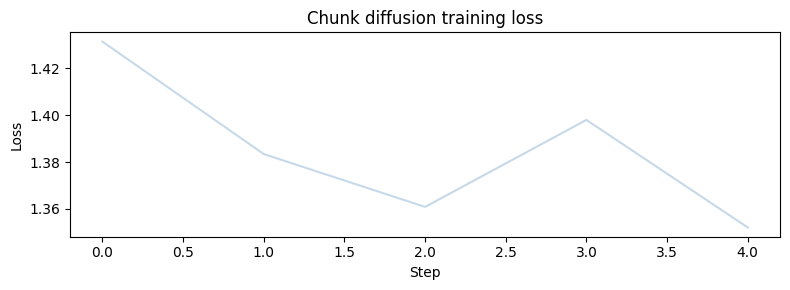

In [19]:
# --- Training loop ---
import matplotlib.pyplot as plt

EPOCHS = 5       # increase for real training
GRAD_CLIP = 1.0

losses = []
diffuser.diffusion.train()

for epoch in range(1, EPOCHS + 1):
    epoch_losses = []
    for batch in tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        # Move tensors to device
        batch_dev = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }

        loss, info = diffuser.loss(batch_dev)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffuser.diffusion.parameters(), GRAD_CLIP)
        optimizer.step()

        losses.append(loss.item())
        epoch_losses.append(loss.item())

    print(f"Epoch {epoch}: mean loss = {np.mean(epoch_losses):.4f}")

# --- Plot loss curve ---
plt.figure(figsize=(8, 3))
plt.plot(losses, alpha=0.3, color="steelblue")
window = min(50, max(1, len(losses) // 5))
if window > 1:
    smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
    plt.plot(range(window - 1, len(losses)), smoothed, color="steelblue", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Chunk diffusion training loss")
plt.tight_layout()
plt.show()

In [20]:
# --- Save trained diffusion model ---
from dataclasses import asdict

ckpt_dir = policy_train_dir / "diffusion_ckpts"
ckpt_dir.mkdir(exist_ok=True)

ckpt_payload = {
    "diffusion_state_dict": diffuser.diffusion.state_dict(),
    "epoch": EPOCHS,
    "step": len(losses),
    "diffusion_config": asdict(diffusion_config),
    "dataset_config": asdict(dataset_config),
    "normalization_stats": {
        "mean": norm_stats.mean,
        "std": norm_stats.std,
    } if norm_stats is not None else None,
}

ckpt_path = ckpt_dir / "sope_diffuser_latest.pt"
torch.save(ckpt_payload, str(ckpt_path))
print(f"Saved diffusion checkpoint to {ckpt_path}")
print(f"  Epochs: {EPOCHS}, Steps: {len(losses)}, Final loss: {losses[-1]:.4f}")

Saved diffusion checkpoint to ../third_party/robomimic/diffusion_policy_trained_models/test/20260309132349/diffusion_ckpts/sope_diffuser_latest.pt
  Epochs: 5, Steps: 5, Final loss: 1.3521


## Step 4: Policy Guidance Setup

> **STATUS: NOT YET IMPLEMENTED**

SOPE's guided sampling requires the target policy to expose `grad_log_prob(state, action)`,
which computes $\nabla_a \log \pi(a \mid s)$ via autograd. Robomimic policies don't have this.

**What needs to be built** (likely in `src/latent_sope/robomimic_interface/guidance.py`):

```python
class RobomimicGuidanceWrapper:
    """Wraps a robomimic policy to expose grad_log_prob for SOPE guidance."""

    def grad_log_prob(self, states, actions):
        # For BC_Gaussian: forward pass → (mean, std), then Gaussian log-prob
        # For BC_GMM: forward pass → mixture params, then log-sum-exp
        # For DiffusionPolicyUNet: use the policy's own diffusion score
        ...
```

**Key constraint:** With `LowDimConcatEncoder`, latents = obs, so the policy can consume
states directly. With `HighDimObsEncoder`, we'd need a latent→obs decoder (hard).

For the MVP, **skip guidance** and sample unguided trajectories. This still gives us a
baseline OPE estimate (sampling from the data distribution rather than the target policy).

In [21]:
# --- Step 4 placeholder: guidance is not yet wired ---
#
# Once RobomimicGuidanceWrapper is built, plug it in like this:
#
#   from src.latent_sope.robomimic_interface.guidance import RobomimicGuidanceWrapper
#
#   target_wrapper = RobomimicGuidanceWrapper(policy, policy_type="gaussian")
#   diffuser.diffusion.policy = target_wrapper
#   diffuser.diffusion.behavior_policy = target_wrapper  # or a separate behavior policy
#
#   # Then in Step 5, pass guided=True:
#   samples = diffuser.diffusion.conditional_sample(
#       shape=..., cond=..., guided=True,
#       action_scale=0.5, use_neg_grad=True, neg_grad_scale=0.1,
#       normalize_grad=True, k_guide=1, use_action_grad_only=True,
#       clamp=True, l_inf=1.0,
#   )
#
# For now, we proceed unguided (guided=False).
print("Step 4: Skipped (guidance not yet implemented). Proceeding unguided.")

Step 4: Skipped (guidance not yet implemented). Proceeding unguided.


## Step 5: Generate Synthetic Trajectories via Stitching

Generate full-length trajectories by autoregressively stitching diffusion chunks.
Each chunk is conditioned on the last `frame_stack` states of the previous chunk.

**Code:** `SopeDiffuser.generate_full_trajectory()` in `sope_diffuser.py`.

In [22]:
# --- Generate synthetic trajectories via stitching ---

from src.latent_sope.diffusion.sope_diffuser import make_normalizers

NUM_TRAJS = 16
MAX_LENGTH = HORIZON  # match oracle horizon

# Sample initial states from offline rollouts
init_states = []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]  # (T, D)
    init_states.append(latents[0])

init_states_t = torch.tensor(np.stack(init_states), dtype=torch.float32)

print(f"Generating {NUM_TRAJS} stitched trajectories (max {MAX_LENGTH} steps)...\n")

syn_states, syn_actions, end_indices = diffuser.generate_full_trajectory(
    initial_states=init_states_t,
    max_length=MAX_LENGTH,
    guided=False,
    verbose=False,
)

print(f"Generated {NUM_TRAJS} trajectories:")
print(f"  states shape: {syn_states.shape}")
print(f"  actions shape: {syn_actions.shape}")
print(f"  state range: [{syn_states.min():.2f}, {syn_states.max():.2f}]")

Generating 16 stitched trajectories (max 60 steps)...


                                                                                                    
1 / 64 [                                                            ]   1% | 16.3 Hz
t : 63
                                                                                                    
                                                                                                    
2 / 64 [#                                                           ]   3% | 27.8 Hz
t : 62
                                                                                                    
                                                                                                    
3 / 64 [##                                                          ]   4% | 36.8 Hz
t : 61
                                                                                                    
                                                              

### Step 5b: Trajectory Reconstruction Quality

Compare generated (stitched) trajectories against the real offline trajectories they were
seeded from. This measures how well the diffusion model reconstructs the actual trajectory
distribution — a sanity check before using the synthetic data for OPE.

**Metric:** `trajectory_reconstruction_mse()` in `eval/metrics.py`.

In [ ]:
# --- Compare generated vs real trajectories ---

from src.latent_sope.eval.metrics import trajectory_reconstruction_mse

# Load real trajectories matching the initial states used for generation
real_states_list = []
real_actions_list = []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]  # (T, D)
    actions = traj_i.actions
    # Truncate or pad to MAX_LENGTH
    T = latents.shape[0]
    if T >= MAX_LENGTH:
        real_states_list.append(latents[:MAX_LENGTH])
        real_actions_list.append(actions[:MAX_LENGTH])
    else:
        pad_s = np.zeros((MAX_LENGTH - T, latents.shape[-1]), dtype=np.float32)
        pad_a = np.zeros((MAX_LENGTH - T, actions.shape[-1]), dtype=np.float32)
        real_states_list.append(np.concatenate([latents, pad_s], axis=0))
        real_actions_list.append(np.concatenate([actions, pad_a], axis=0))

real_states = np.stack(real_states_list)   # (B, T, state_dim)
real_actions = np.stack(real_actions_list)  # (B, T, action_dim)

recon_err = trajectory_reconstruction_mse(
    real_states=real_states,
    gen_states=syn_states,
    real_actions=real_actions,
    gen_actions=syn_actions,
    end_indices=end_indices,
)

print(f"Trajectory Reconstruction MSE ({recon_err.num_trajectories} trajectories, {recon_err.trajectory_length} steps):")
print(f"  State MSE:  {recon_err.state_mse:.6f}")
print(f"  Action MSE: {recon_err.action_mse:.6f}")
print()

# Per-dimension state MSE breakdown (using latent vector layout)
dim_labels = (
    ["obj_pos_x", "obj_pos_y", "obj_pos_z"] +
    ["obj_quat_w", "obj_quat_x", "obj_quat_y", "obj_quat_z"] +
    ["grip_to_cube_x", "grip_to_cube_y", "grip_to_cube_z"] +
    ["eef_pos_x", "eef_pos_y", "eef_pos_z"] +
    ["eef_quat_w", "eef_quat_x", "eef_quat_y", "eef_quat_z"] +
    ["gripper_q0", "gripper_q1"]
)
print("Per-dimension state MSE:")
for dim_i, (label, mse_val) in enumerate(zip(dim_labels, recon_err.state_mse_per_dim)):
    print(f"  [{dim_i:2d}] {label:20s}: {mse_val:.6f}")

print(f"\nPer-step state MSE (first 10 / last 10):")
for t in list(range(min(10, recon_err.trajectory_length))) + list(range(max(0, recon_err.trajectory_length - 10), recon_err.trajectory_length)):
    print(f"  t={t:3d}: state={recon_err.state_mse_per_step[t]:.6f}  action={recon_err.action_mse_per_step[t]:.6f}")

## Step 6: Score Trajectories (Reward Estimation)

Score synthetic trajectories using the **ground-truth reward function** for Lift.

Since we use `LowDimConcatEncoder` (latents = concatenated obs), we can decode latents
back to an obs dict and check the cube z-position directly against the success threshold.

**Code:** `eval/reward_model.py` — `LiftRewardFn`, `score_trajectories_gt()`.

In [23]:
# --- Score synthetic trajectories with ground-truth reward ---

from src.latent_sope.eval.reward_model import LiftRewardFn, score_trajectories_gt, make_lift_encoder

# Build encoder configured for Lift obs decoding (single-frame dims, not frame_stack)
encoder = make_lift_encoder(obs_keys=obs_keys)

# Ground-truth reward: cube z > table_height + 0.04
reward_fn = LiftRewardFn(table_height=0.8, height_threshold=0.04)
print(f"Reward function: {reward_fn}")

# Score synthetic trajectories
synthetic_returns, synthetic_rewards = score_trajectories_gt(
    reward_fn=reward_fn,
    encoder=encoder,
    states=syn_states,
    actions=syn_actions,
    gamma=gamma,
)

print(f"\nSynthetic trajectory returns (gamma={gamma}):")
print(f"  mean = {synthetic_returns.mean():.3f}, std = {synthetic_returns.std():.3f}")
print(f"  per-trajectory: {[f'{r:.2f}' for r in synthetic_returns]}")

# Diagnostic: check cube z-positions in synthetic trajectories
obs_sample = encoder.decode_to_obs_dict(syn_states[0])
cube_z = obs_sample["object"][:, 2]
print(f"\nDiagnostic — trajectory 0 cube z-positions:")
print(f"  range: [{cube_z.min():.4f}, {cube_z.max():.4f}]")
print(f"  success threshold: {reward_fn.success_z:.4f}")
print(f"  steps above threshold: {(cube_z > reward_fn.success_z).sum()} / {len(cube_z)}")

Reward function: LiftRewardFn(table_height=0.8, height_threshold=0.04, success_z=0.8400)

Synthetic trajectory returns (gamma=1.0):
  mean = 29.062, std = 2.749
  per-trajectory: ['27.00', '27.00', '27.00', '30.00', '34.00', '30.00', '24.00', '30.00', '32.00', '26.00', '26.00', '30.00', '30.00', '34.00', '30.00', '28.00']

Diagnostic — trajectory 0 cube z-positions:
  range: [-3.6327, 4.4031]
  success threshold: 0.8400
  steps above threshold: 27 / 60


## Step 7: Evaluate the OPE Estimate

Compare the OPE estimate (mean return over synthetic trajectories) to the oracle value
from Step 0.

**Code:** `eval/metrics.py` — `ope_eval()`.

In [24]:
# --- OPE evaluation: compare estimate to oracle ---

from src.latent_sope.eval.metrics import ope_eval

result = ope_eval(oracle_value, synthetic_returns)

print("=" * 50)
print("OPE Evaluation")
print("=" * 50)
print(f"  Oracle V^pi:      {result.oracle_value:.3f}")
print(f"  OPE estimate:     {result.ope_estimate:.3f} (std={result.ope_std:.3f})")
print(f"  MSE:              {result.mse:.6f}")
print(f"  Relative error:   {result.relative_error:.2%}")
print("=" * 50)

OPE Evaluation
  Oracle V^pi:      0.400
  OPE estimate:     29.062 (std=2.749)
  MSE:              821.538906
  Relative error:   7165.62%
